In [1]:
!pip install kagglehub

import kagglehub
path = kagglehub.dataset_download("alessiocorrado99/animals10")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animals10' dataset.
Path to dataset files: /kaggle/input/animals10


In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("alessiocorrado99/animals10")
print("✅ Dataset downloaded at:", path)

# Step 2: Now check folders
raw_path = os.path.join(path, 'raw-img')
print("Folders found:", os.listdir(raw_path))


Using Colab cache for faster access to the 'animals10' dataset.
✅ Dataset downloaded at: /kaggle/input/animals10
Folders found: ['cavallo', 'pecora', 'elefante', 'gatto', 'scoiattolo', 'gallina', 'ragno', 'mucca', 'cane', 'farfalla']


In [6]:
# CELL 4 — Copy dataset to writable folder, then rename
import shutil
import os

# Step 1: Copy from read-only kaggle folder to writable folder
src_dir = '/kaggle/input/animals10/raw-img'   # read-only
dst_dir = '/content/animals10/raw-img'        # writable ✅

print("📦 Copying dataset... (takes 1-2 minutes)")
shutil.copytree(src_dir, dst_dir)
print("✅ Copy complete!")

# Step 2: Update raw_path to new writable location
raw_path = dst_dir
print("📂 Folders found:", os.listdir(raw_path))

📦 Copying dataset... (takes 1-2 minutes)
✅ Copy complete!
📂 Folders found: ['gallina', 'cavallo', 'mucca', 'elefante', 'pecora', 'scoiattolo', 'cane', 'farfalla', 'ragno', 'gatto']


In [7]:
# CELL 4b — Now rename safely
italian_map = {
    'gatto':      'cat',
    'cane':       'dog',
    'cavallo':    'horse',
    'elefante':   'elephant',
    'farfalla':   'butterfly',
    'gallina':    'chicken',
    'mucca':      'cow',
    'pecora':     'sheep',
    'ragno':      'spider',
    'scoiattolo': 'squirrel'
}

for italian, english in italian_map.items():
    src = os.path.join(raw_path, italian)
    dst = os.path.join(raw_path, english)
    if os.path.exists(src):
        os.rename(src, dst)
        print(f"✅ Renamed: {italian} → {english}")
    else:
        print(f"⚠️  Not found: {italian}")

print("\n📂 Folders after renaming:", os.listdir(raw_path))


✅ Renamed: gatto → cat
✅ Renamed: cane → dog
✅ Renamed: cavallo → horse
✅ Renamed: elefante → elephant
✅ Renamed: farfalla → butterfly
✅ Renamed: gallina → chicken
✅ Renamed: mucca → cow
✅ Renamed: pecora → sheep
✅ Renamed: ragno → spider
✅ Renamed: scoiattolo → squirrel

📂 Folders after renaming: ['chicken', 'elephant', 'cat', 'squirrel', 'dog', 'sheep', 'spider', 'butterfly', 'cow', 'horse']


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [31]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS     = 30
CLASSES    = ['cat', 'dog', 'horse', 'elephant']
DATA_DIR   = raw_path    # /content/animals10/raw-img

print("✅ Configuration Set:")
print(f"   Image Size  : {IMG_SIZE}")
print(f"   Batch Size  : {BATCH_SIZE}")
print(f"   Epochs      : {EPOCHS}")
print(f"   Classes     : {CLASSES}")
print(f"   Data Dir    : {DATA_DIR}")

✅ Configuration Set:
   Image Size  : (128, 128)
   Batch Size  : 32
   Epochs      : 30
   Classes     : ['cat', 'dog', 'horse', 'elephant']
   Data Dir    : /content/animals10/raw-img


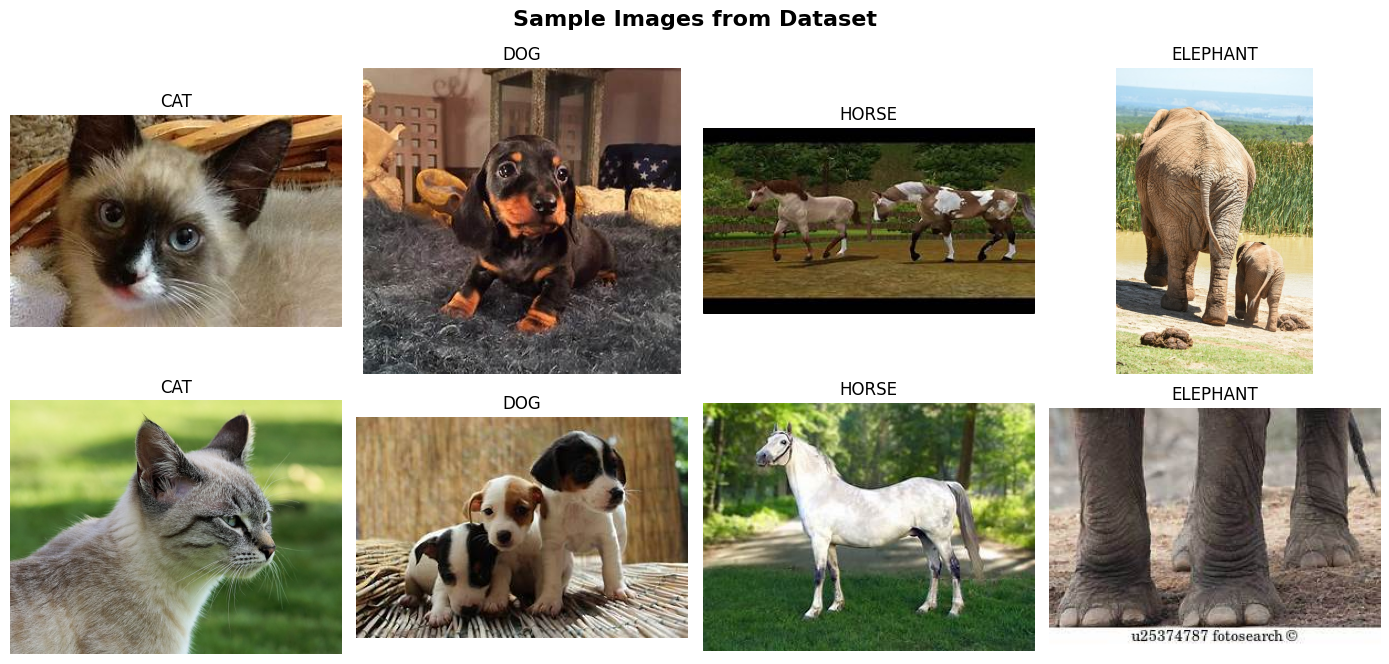

✅ Sample images displayed!


In [32]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')

for idx, animal in enumerate(CLASSES):
    folder = os.path.join(DATA_DIR, animal)
    images = os.listdir(folder)[:2]
    for j, img_name in enumerate(images):
        img_path = os.path.join(folder, img_name)
        try:
            img = plt.imread(img_path)
            axes[j][idx].imshow(img)
            axes[j][idx].set_title(f'{animal.upper()}', fontsize=12)
            axes[j][idx].axis('off')
        except:
            axes[j][idx].axis('off')

plt.tight_layout()
plt.show()
print("✅ Sample images displayed!")

In [33]:
def make_generators(augment=False):
    if augment:
        train_datagen = ImageDataGenerator(
            rescale           = 1./255,
            validation_split  = 0.2,
            rotation_range    = 20,
            width_shift_range = 0.2,
            height_shift_range= 0.2,
            horizontal_flip   = True
        )
    else:
        train_datagen = ImageDataGenerator(
            rescale          = 1./255,
            validation_split = 0.2
        )

    val_datagen = ImageDataGenerator(
        rescale          = 1./255,
        validation_split = 0.2
    )

    train_generator = train_datagen.flow_from_directory(
        DATA_DIR,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        classes     = CLASSES,
        subset      = 'training',
        shuffle     = True
    )

    val_generator = val_datagen.flow_from_directory(
        DATA_DIR,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        classes     = CLASSES,
        subset      = 'validation',
        shuffle     = False
    )

    return train_generator, val_generator

print("✅ Data generator function ready!")

✅ Data generator function ready!


In [34]:
def build_basic_cnn():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu',
                      input_shape=(128, 128, 3)),
        layers.MaxPooling2D(2, 2),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(4, activation='softmax')
    ])
    return model

model1 = build_basic_cnn()
model1.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
def build_dropout_cnn():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu',
                      input_shape=(128, 128, 3)),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4, activation='softmax')
    ])
    return model

model2 = build_dropout_cnn()
model2.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
print("=" * 50)
print("🚀 Training Model 1: Basic CNN")
print("=" * 50)

model1.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

train_ds1, val_ds1 = make_generators(augment=False)

history1 = model1.fit(
    train_ds1,
    validation_data = val_ds1,
    epochs          = EPOCHS,
    verbose         = 1
)

model1.save('basic_cnn.h5')
_, acc1 = model1.evaluate(val_ds1, verbose=0)
print(f"\n✅ Basic CNN Accuracy: {acc1*100:.2f}%")

🚀 Training Model 1: Basic CNN
Found 8482 images belonging to 4 classes.
Found 2118 images belonging to 4 classes.
Epoch 1/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - accuracy: 0.4993 - loss: 1.1535 - val_accuracy: 0.6582 - val_loss: 0.8406
Epoch 2/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - accuracy: 0.6776 - loss: 0.8065 - val_accuracy: 0.6926 - val_loss: 0.7591
Epoch 3/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - accuracy: 0.7406 - loss: 0.6351 - val_accuracy: 0.7266 - val_loss: 0.7451
Epoch 4/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.8171 - loss: 0.4925 - val_accuracy: 0.7389 - val_loss: 0.7003
Epoch 5/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.8721 - loss: 0.3372 - val_accuracy: 0.7290 - val_loss: 0.8187
Epoch 6/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 18s 67ms/step - accuracy: 0.9345 - loss: 0.1810 - val_accuracy: 0.7323 - val_loss: 0.8953
Epoch 7/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.9643 - loss: 0.1066 - val_accuracy: 0.


✅ Basic CNN Accuracy: 74.93%


In [37]:
print("=" * 50)
print("🚀 Training Model 2: CNN + Dropout")
print("=" * 50)

model2.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

train_ds2, val_ds2 = make_generators(augment=False)

history2 = model2.fit(
    train_ds2,
    validation_data = val_ds2,
    epochs          = EPOCHS,
    verbose         = 1
)

model2.save('dropout_cnn.h5')
_, acc2 = model2.evaluate(val_ds2, verbose=0)
print(f"\n✅ CNN + Dropout Accuracy: {acc2*100:.2f}%")

🚀 Training Model 2: CNN + Dropout
Found 8482 images belonging to 4 classes.
Found 2118 images belonging to 4 classes.
Epoch 1/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 27s 83ms/step - accuracy: 0.4499 - loss: 1.3369 - val_accuracy: 0.5524 - val_loss: 1.0688
Epoch 2/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - accuracy: 0.5697 - loss: 1.0515 - val_accuracy: 0.6294 - val_loss: 0.9279
Epoch 3/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.6089 - loss: 0.9268 - val_accuracy: 0.6582 - val_loss: 0.8332
Epoch 4/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - accuracy: 0.6393 - loss: 0.8505 - val_accuracy: 0.6714 - val_loss: 0.7808
Epoch 5/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - accuracy: 0.6817 - loss: 0.7691 - val_accuracy: 0.7044 - val_loss: 0.7008
Epoch 6/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - accuracy: 0.7178 - loss: 0.7044 - val_accuracy: 0.7054 - val_loss: 0.7134
Epoch 7/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - accuracy: 0.7346 - loss: 0.6487 - val_accuracy


✅ CNN + Dropout Accuracy: 76.96%


In [38]:
print("=" * 50)
print("🚀 Training Model 3: CNN + Augmentation")
print("=" * 50)

model3 = build_basic_cnn()
model3.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

train_ds3, val_ds3 = make_generators(augment=True)

history3 = model3.fit(
    train_ds3,
    validation_data = val_ds3,
    epochs          = EPOCHS,
    verbose         = 1
)

model3.save('augmented_cnn.h5')
_, acc3 = model3.evaluate(val_ds3, verbose=0)
print(f"\n✅ CNN + Augmentation Accuracy: {acc3*100:.2f}%")

🚀 Training Model 3: CNN + Augmentation
Found 8482 images belonging to 4 classes.
Found 2118 images belonging to 4 classes.
Epoch 1/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 52s 183ms/step - accuracy: 0.4714 - loss: 1.2430 - val_accuracy: 0.5840 - val_loss: 0.9997
Epoch 2/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 46s 173ms/step - accuracy: 0.5698 - loss: 1.0404 - val_accuracy: 0.6218 - val_loss: 0.8959
Epoch 3/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 46s 175ms/step - accuracy: 0.5974 - loss: 0.9614 - val_accuracy: 0.6232 - val_loss: 0.8838
Epoch 4/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 46s 174ms/step - accuracy: 0.6307 - loss: 0.8972 - val_accuracy: 0.6558 - val_loss: 0.8691
Epoch 5/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 45s 170ms/step - accuracy: 0.6622 - loss: 0.8242 - val_accuracy: 0.7054 - val_loss: 0.7617
Epoch 6/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 46s 174ms/step - accuracy: 0.6775 - loss: 0.7898 - val_accuracy: 0.7262 - val_loss: 0.6891
Epoch 7/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 46s 174ms/step - accuracy: 0.7051 - loss: 0.7265 - 


✅ CNN + Augmentation Accuracy: 75.73%


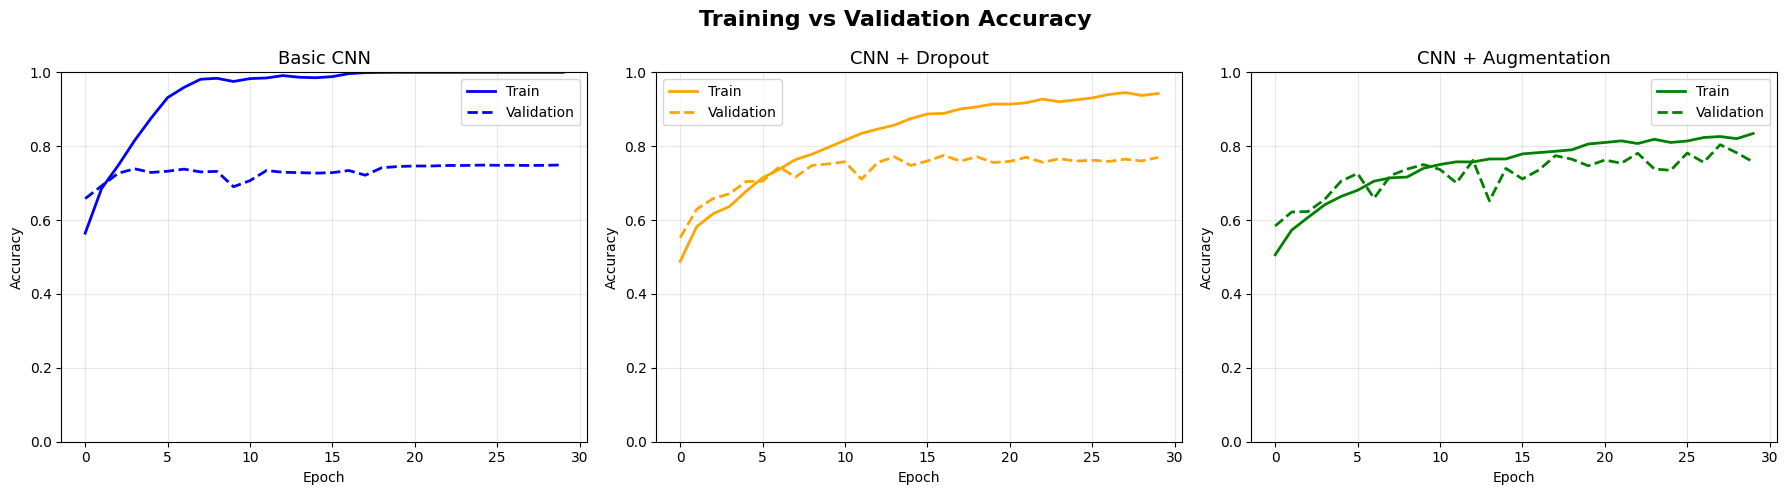

✅ Training curves saved!


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training vs Validation Accuracy',
             fontsize=16, fontweight='bold')

histories = [
    (history1, 'Basic CNN',           'blue'),
    (history2, 'CNN + Dropout',       'orange'),
    (history3, 'CNN + Augmentation',  'green')
]

for ax, (hist, name, color) in zip(axes, histories):
    ax.plot(hist.history['accuracy'],
            label='Train', color=color, linewidth=2)
    ax.plot(hist.history['val_accuracy'],
            label='Validation', color=color,
            linewidth=2, linestyle='--')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("✅ Training curves saved!")


Model                       Accuracy
Basic CNN                     74.93%  ██████████████
CNN + Dropout                 76.96%  ███████████████
CNN + Augmentation            75.73%  ███████████████
🏆 Best Model: CNN + Dropout


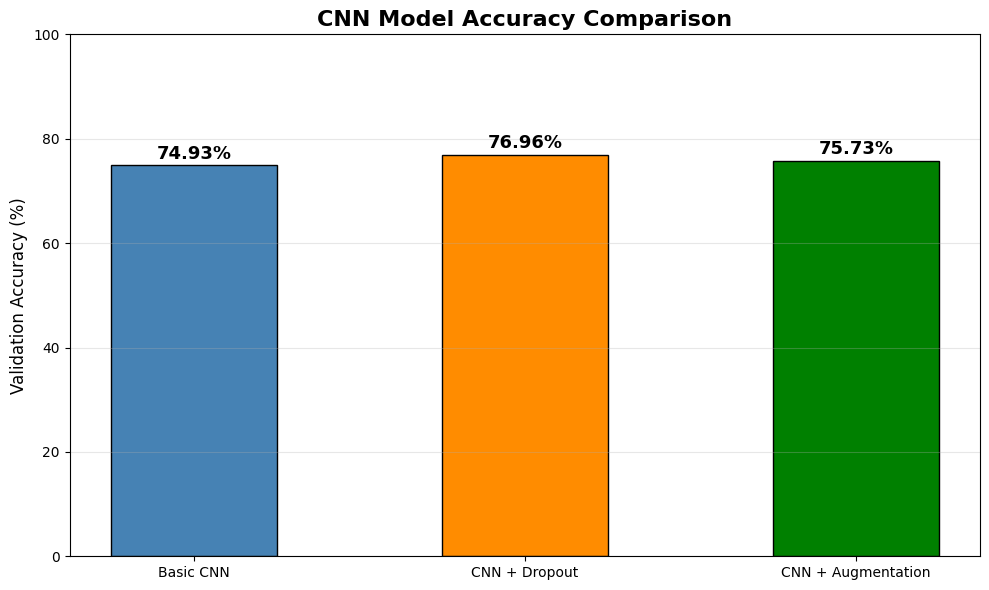

In [40]:
# Results dictionary
results = {
    'Basic CNN':           round(acc1 * 100, 2),
    'CNN + Dropout':       round(acc2 * 100, 2),
    'CNN + Augmentation':  round(acc3 * 100, 2)
}

# Print table
print("\n" + "="*45)
print(f"{'Model':<25} {'Accuracy':>10}")
print("="*45)
for name, acc in results.items():
    bar = "█" * int(acc // 5)
    print(f"{name:<25} {acc:>9}%  {bar}")
print("="*45)
print(f"🏆 Best Model: {max(results, key=results.get)}")

# Bar chart
plt.figure(figsize=(10, 6))
colors = ['steelblue', 'darkorange', 'green']
bars = plt.bar(results.keys(), results.values(),
               color=colors, width=0.5, edgecolor='black')

for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center', va='bottom',
             fontsize=13, fontweight='bold')

plt.title('CNN Model Accuracy Comparison',
          fontsize=16, fontweight='bold')
plt.ylabel('Validation Accuracy (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

🔍 Testing Model 3 (Best Model) on sample images:



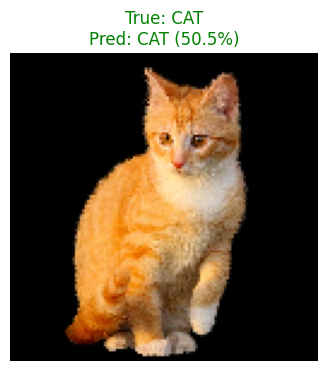

  cat        → Predicted: cat        (50.5%)


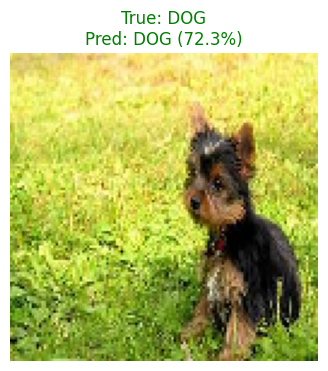

  dog        → Predicted: dog        (72.3%)


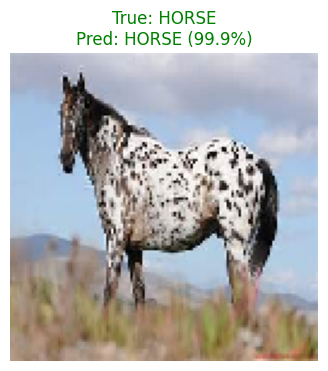

  horse      → Predicted: horse      (99.9%)


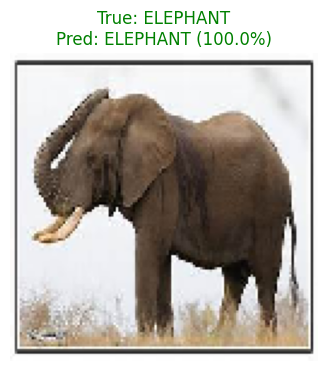

  elephant   → Predicted: elephant   (100.0%)


In [41]:
from tensorflow.keras.preprocessing import image

def predict_animal(model, img_path, true_label="Unknown"):
    img       = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction      = model.predict(img_array, verbose=0)
    predicted_class = CLASSES[np.argmax(prediction)]
    confidence      = np.max(prediction) * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(image.load_img(img_path, target_size=IMG_SIZE))
    plt.title(
        f'True: {true_label.upper()}\n'
        f'Pred: {predicted_class.upper()} ({confidence:.1f}%)',
        fontsize=12,
        color='green' if predicted_class == true_label else 'red'
    )
    plt.axis('off')
    plt.show()
    return predicted_class, confidence

# Test one image from each animal class
print("🔍 Testing Model 3 (Best Model) on sample images:\n")
for animal in CLASSES:
    folder   = os.path.join(DATA_DIR, animal)
    test_img = os.path.join(folder, os.listdir(folder)[5])
    pred, conf = predict_animal(model3, test_img, true_label=animal)
    print(f"  {animal:<10} → Predicted: {pred:<10} ({conf:.1f}%)")
